# Skin Lesion Classification using CNN

## Semester Project – Programming for AI

### Team Members
- bscs24043 Ibrahim Butt
- bscs24095 Waize Arif
- bscs24139 Syed Jaffar Raza Kazmi
- bscs24083 Muhammad Moiz

### Objective
Build a Convolutional Neural Network (CNN) model to classify skin lesion images.

# Python Imports

In [1]:
!pip install torchmetrics
!pip install gradio
import torch
import torchvision
from torch.utils.data import DataLoader, Subset
import torchmetrics
from torchmetrics import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from timeit import default_timer as timer
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import gradio as gr
import torch.nn.functional as F
from PIL import Image


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!cp "/content/drive/MyDrive/skin_lesion/skin_datasetv2.zip" "/content/"

!unzip -q "/content/skin_datasetv2.zip" -d "/content/"

!ls "/content/dataset"

replace /content/dataset/healthy/healthy_30.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
acne  bruises  burn  healthy  pigmentation


# Check Version and Device

In [4]:
print(f"PyTorchColab Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

PyTorchColab Version: 2.10.0+cu128
Torchvision Version: 0.25.0+cu128
Using device: cuda


# HyperParameters

In [5]:
# --- HYPERPARAMETER DASHBOARD ---

SEED = 42                # seed for reproducibility
TRAIN_SPLIT = 0.8        # train test split value, 80% train, 20% test
BATCH_SIZE = 16          # lower if model getting stuck
LEARNING_RATE = 0.0003   # rate of learning
EPOCHS = 60              # Itterations, more for difficult learning
DROPOUT_RATE = 0.3       # Kills 30% of neurons randomly to stop memorization
IMAGE_SIZE = 224         # image size

# Transformin data

In [6]:
# DATA TRANSFORMING

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomVerticalFlip(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
print("Transforms defined successfully.")

Transforms defined successfully.


# Data Loading

In [7]:
dataset_path = "/content/dataset"

train_data_full = ImageFolder(root=dataset_path, transform=train_transforms)
test_data_full  = ImageFolder(root=dataset_path, transform=test_transforms)

# 80 20 split
total_images = len(train_data_full)
train_count = int(TRAIN_SPLIT * total_images)

# Generate a shared list of shuffled numbers

indices = torch.randperm(total_images).tolist()

# train and test sets
train_dataset = Subset(train_data_full, indices[:train_count])
test_dataset  = Subset(test_data_full, indices[train_count:])

# Loaders made
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Data loaded correctly. Train and Test are safely separated.")

Data loaded correctly. Train and Test are safely separated.


# The CNN class

In [8]:
import torch.nn as nn

class SkinCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(DROPOUT_RATE)

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, 5)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.flatten(x)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SkinCNN().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("CNN built and pushed to GPU.")


CNN built and pushed to GPU.


# Training Loop

In [9]:
best_test_acc = 0.0
loss_history = []
train_acc_history = []
test_acc_history = []

print(f"Training started for {EPOCHS} epochs. Please wait...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    loss_history.append(epoch_loss)
    train_acc_history.append(train_acc)

    model.eval()
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_acc = 100 * test_correct / test_total
    test_acc_history.append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_skin_model.pth')
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% <<< NEW HIGH SCORE! SAVED.")
    else:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("\n--- Training Complete! ---")
print(f"Final Training Accuracy: {train_acc_history[-1]:.2f}%")
print(f"Final Test Accuracy: {test_acc_history[-1]:.2f}%")
print(f"Absolute Best Test Accuracy Saved: {best_test_acc:.2f}%")

Training started for 60 epochs. Please wait...

Training Complete!
Final Training Accuracy: 83.89%
Final Test Accuracy: 71.86%
Absolute Best Test Accuracy Saved: 76.65%


# Accuracy and Prediction checking

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=train_data_full.classes))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data_full.classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Actual vs Predicted")
plt.show()

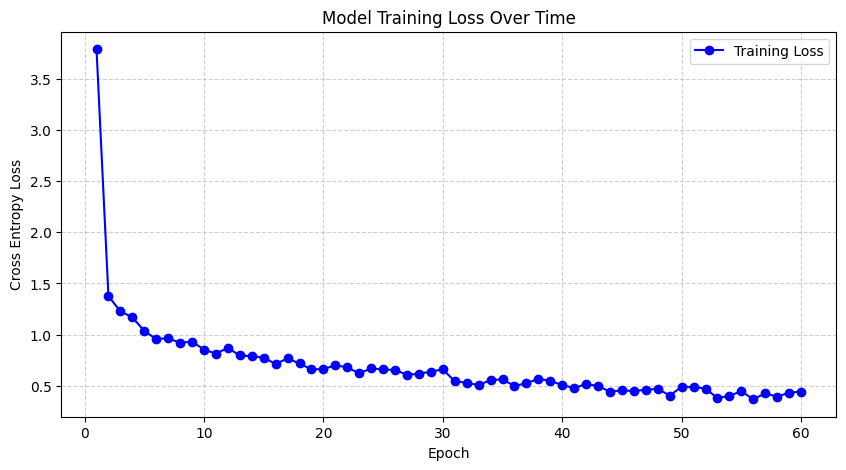

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', color='b', label='Training Loss')
plt.title("Model Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

# Plot images
fig = plt.figure(figsize=(15, 6))
for idx in range(6):
    ax = fig.add_subplot(1, 6, idx+1, xticks=[], yticks=[])

    img = images[idx] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

    true_label = train_data_full.classes[labels[idx]]
    pred_label = train_data_full.classes[preds[idx]]

    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()

# Gradio Demo

In [ ]:

class_names = ['acne', 'bruises', 'burn', 'healthy' , 'pigmentation']

demo_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

model.load_state_dict(torch.load('best_skin_model.pth', map_location=device))
model.eval()

def predict_skin_lesion(img):
    if img is None:
        return None

    img = img.convert('RGB')

    input_tensor = demo_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output[0], dim=0)

    result_dict = {class_names[i]: float(probabilities[i]) for i in range(len(class_names))}
    return result_dict

demo = gr.Interface(
    fn=predict_skin_lesion,
    inputs=gr.Image(type="pil", label="Upload Skin Image"),
    outputs=gr.Label(num_top_classes=5, label="Model Predictions"),
    title="⚕️ Skin Lesion Classifier AI",
    description="Upload an image of a skin lesion. The CNN will analyze the textures and predict the condition.",
    allow_flagging="never",
    theme=gr.themes.Soft()
)

demo.launch(share=True, debug=True)